# ControlGap: a tour

Companion to [*The AI Drake Equation*](../paper/ai-drake-equation-v4.md). Each section reproduces one part of the
paper with the `controlgap` package, then lets you change the inputs.

Every number below is **illustrative**. The model cannot produce a trustworthy absolute probability, and says so.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import controlgap as cg
from controlgap import plots, precursors
from controlgap.mc import MCConfig, simulate, spread_decomposition

plt.rcParams.update(plots.STYLE)
S1, S2, S3, INK2 = plots.S1, plots.S2, plots.S3, plots.INK2

## 1. One scenario, four answers (§12)

The product of the factors is **not** a probability. It becomes one only after you pick the baseline rate λ₀,
the least-known number in the model.

In [2]:
s = cg.Scenario("illustrative", C=0.20, A=0.70, O=0.50, X=0.60,
                effectiveness=(0.6, 0.5, 0.5), rho=0.1, p_I=0.5)
print(s)
for lam0 in (0.01, 0.1, 1, 10):
    print(f"lambda0 = {lam0:>5}:  P(catastrophe in 10 yr) = {s.probability(lam0, T=10):.2%}")

Scenario('illustrative', V=0.19, factor=0.00399)
lambda0 =  0.01:  P(catastrophe in 10 yr) = 0.04%
lambda0 =   0.1:  P(catastrophe in 10 yr) = 0.40%
lambda0 =     1:  P(catastrophe in 10 yr) = 3.91%
lambda0 =    10:  P(catastrophe in 10 yr) = 32.90%


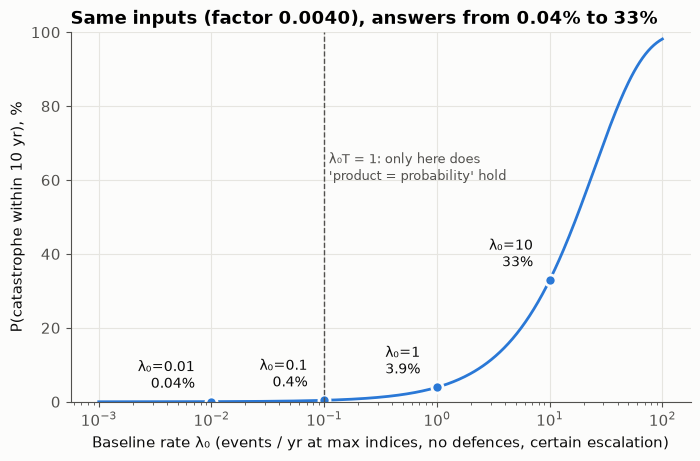

In [3]:
plots.fig_lambda0_identifiability(s);

## 2. The common-mode floor (§6.2)

`V = ρ + (1 − ρ) ∏(1 − e)`. Once the layers are good, only reducing ρ helps. The floor is a hypothesis, not a result.

e = 0.6:  V = 0.0827   (rho = 0.02)
e = 0.9:  V = 0.0210   (rho = 0.02)
e = 0.99:  V = 0.0200   (rho = 0.02)


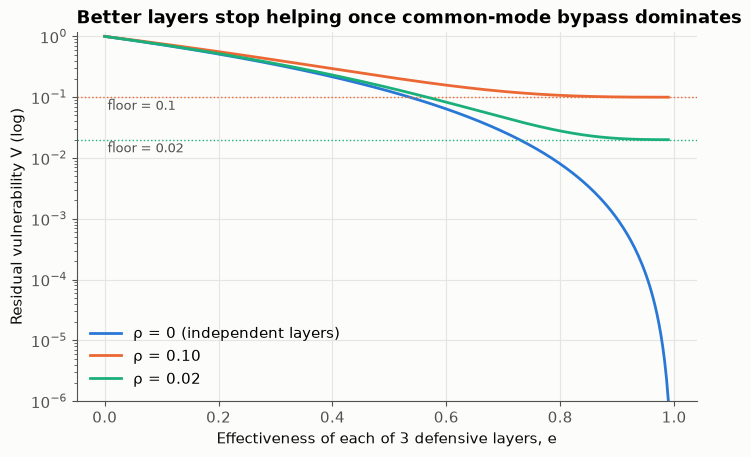

In [4]:
for e in (0.6, 0.9, 0.99):
    print(f"e = {e}:  V = {cg.residual_vulnerability([e] * 3, rho=0.02):.4f}   (rho = 0.02)")
plots.fig_common_mode_floor();

## 3. Power law or threshold? (§6.5)

The gate is normalised so that g(0) = 0 and g(1) = 1, which keeps the conjunction property.

C=0.3, A=0.3:  Spec I = 0.090   Spec II = 0.002
C=0.3, A=0.8:  Spec I = 0.240   Spec II = 0.046
C=0.6, A=0.8:  Spec I = 0.480   Spec II = 0.809


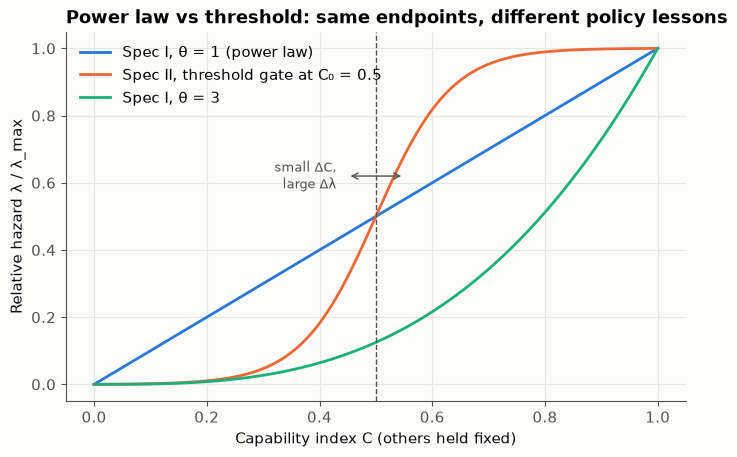

In [5]:
gates = {"C": cg.Gate(z0=0.5, k=15), "A": cg.Gate(z0=0.5, k=15)}
for C, A in [(0.3, 0.3), (0.3, 0.8), (0.6, 0.8)]:
    print(f"C={C}, A={A}:  Spec I = {cg.index_term(C, A, 1, 1):.3f}   Spec II = {cg.index_term(C, A, 1, 1, gates=gates):.3f}")
plots.fig_spec1_vs_spec2();

## 4. Propensity and capability coupling (§6.1, §6.7)

Two additions in v4 of the paper.

- **Propensity `M`**: would the acting agent, human or AI, try? `M = 1` is the worst case and the default.
- **Coupling**: capability erodes the other terms. A capable system acquires access, agency and exposure, and evades oversight.

M = 1.0 : 0.00399
M = 0.25: 0.0009975


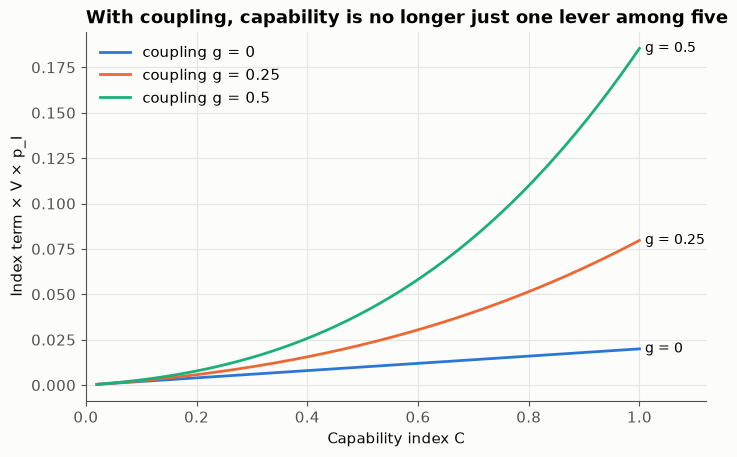

In [6]:
base = dict(A=0.70, O=0.50, X=0.60, effectiveness=(0.6, 0.5, 0.5), rho=0.1, p_I=0.5)
print("M = 1.0 :", cg.Scenario("s", C=0.2, **base).factor)
print("M = 0.25:", cg.Scenario("s", C=0.2, M=0.25, **base).factor)

C = np.linspace(0.02, 1, 200)
fig, ax = plt.subplots(figsize=(8, 4.8))
for g, colour in [(0.0, S1), (0.25, S2), (0.5, S3)]:
    coupling = cg.Coupling(A=g, O=g, X=g, e=g, rho=g)
    factor = cg.Scenario("s", C=C, coupling=coupling, **base).factor
    ax.plot(C, factor, color=colour, label=f"coupling g = {g:g}")
    ax.text(1.01, factor[-1], f"g = {g:g}", va="center", fontsize=10)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Capability index C")
ax.set_ylabel("Index term × V × p_I")
ax.set_title("With coupling, capability is no longer just one lever among five")
ax.legend(loc="upper left");

## 5. The Control Gap Index (§7, §15)

Build the dashboard scenario from raw yearly inputs. `cgi_contributions` splits the index into the part due to each term.

In [7]:
years = np.arange(2026, 2037)
t = years - years[0]
dash = cg.Scenario("autonomous cyber operations",
    nu=1.10**t, C=0.2 * 1.05**t, A=0.7 * 1.02**t, O=0.5 * 1.04**t, X=0.6 * 1.03**t,
    effectiveness=(0.60 + 0.015 * t, 0.50 + 0.01 * t, 0.5),   # detection and intervention improving
    rho=0.10 + 0.004 * t,                                      # independence getting worse
    p_I=cg.irreversibility(r_esc=1.0, tau_rec=1.0 * 0.97**t))  # recovery getting faster

cgi = cg.scenario_cgi(dash)
slope = cg.cgi_slope(t, cgi)
print(dash)
print(f"CGI slope {slope:+.3f} per year  ->  hazard growing {cg.hazard_growth(slope):.0%} per year")

Scenario('autonomous cyber operations', 11 time steps, factor 0.00399 -> 0.0129)
CGI slope +0.213 per year  ->  hazard growing 24% per year


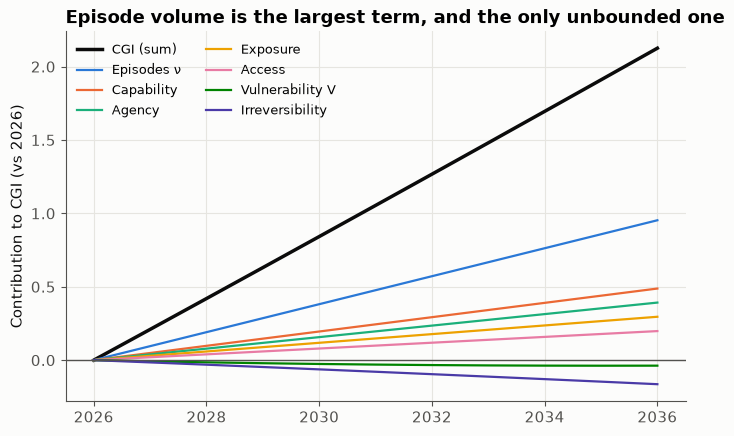

In [8]:
parts = cg.cgi_contributions(dash)
labels = {"nu": "Episodes ν", "C": "Capability", "O": "Agency", "X": "Exposure", "A": "Access", "V": "Vulnerability V", "p_I": "Irreversibility"}
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(years, cgi, color=plots.INK, lw=2.5, label="CGI (sum)")
for (key, label), colour in zip(labels.items(), [S1, S2, S3, "#eda100", "#e87ba4", "#008300", "#4a3aa7"]):
    ax.plot(years, parts[key], color=colour, lw=1.6, label=label)
ax.axhline(0, color=INK2, lw=1)
ax.set_ylabel(f"Contribution to CGI (vs {years[0]})")
ax.set_title("Episode volume is the largest term, and the only unbounded one")
ax.legend(loc="upper left", ncols=2, fontsize=9);

## 6. Monte Carlo (§10)

Average **probabilities**, never hazards. Most of the 2.5 orders of magnitude is the assumed uncertainty in λ₀.
The effect of correlation is the real output.

copula r = 0.0: median 0.22%  mean 0.94%  90% interval spans 2.54 orders


copula r = 0.6: median 0.23%  mean 1.22%  90% interval spans 2.85 orders



Spread, in orders of magnitude: {'all': 2.54, 'lambda0_only': 2.13, 'without_lambda0': 1.39}


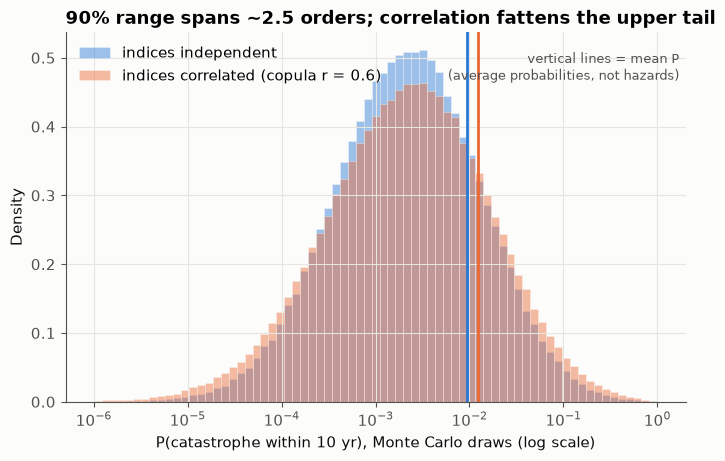

In [9]:
for r in (0.0, 0.6):
    m = simulate(MCConfig(correlation=r)).summary()
    print(f"copula r = {r}: median {m['median']:.2%}  mean {m['mean']:.2%}  90% interval spans {m['orders_of_magnitude_90']:.2f} orders")
print()
print("Spread, in orders of magnitude:", {k: round(v, 2) for k, v in spread_decomposition().items()})
plots.fig_monte_carlo();

## 7. Precursors (§9)

Turn red-team and incident counts into the control-side parameters, score a near-miss, and fit the elasticities.

In [10]:
detection = precursors.layer_effectiveness(stopped=42, challenges=60)
rho = precursors.common_mode_rate(full_bypasses=3, challenges=60)
race = precursors.race_rates(durations=[2, 5, 1, 8, 3, 4], escalated=[0, 0, 1, 0, 0, 1])
print(f"detection e = {detection.mean:.2f}, 90% interval {tuple(round(v, 2) for v in detection.interval())}")
print(f"rho = {rho.mean:.3f},  p_I = {race.p_I:.2f},  mean time to recover = {race.tau_rec:.1f}")

# These estimates plug straight into the Monte Carlo.
print(simulate(MCConfig(effectiveness=detection, rho=rho), n=50_000).summary())

detection e = 0.69, 90% interval (0.59, 0.79)
rho = 0.065,  p_I = 0.33,  mean time to recover = 5.8
{'mean': 0.0056303033820175935, 'median': 0.001328219419051198, 'q05': 7.074684322484177e-05, 'q95': 0.022952422622049475, 'orders_of_magnitude_90': 2.5111214658629564}


In [11]:
# A near-miss that got past two of three layers. Passing layers is evidence of a common-cause bypass.
score = precursors.conditional_catastrophe_probability(passed=[0.6, 0.5], remaining=[0.5], rho=0.1, p_I=0.5)
print(f"conditional catastrophe probability: {score:.2f}   (naive: {(1 - 0.5) * 0.5:.2f})")

conditional catastrophe probability: 0.34   (naive: 0.25)


In [12]:
# Fitting elasticities: synthetic precursor counts with a known answer (theta_A = 1.5, theta_O = 0.7).
rng = np.random.default_rng(0)
n = 300
nu, A, O = rng.uniform(1e4, 1e5, n), rng.uniform(0.1, 1, n), rng.uniform(0.1, 1, n)
counts = rng.poisson(nu * 1e-3 * A**1.5 * O**0.7)
fit = precursors.fit_elasticities(counts, nu, {"A": A, "O": O})
for name in fit.theta:
    lo, hi = fit.interval(name)
    print(f"theta_{name} = {fit.theta[name]:.2f}   90% interval ({lo:.2f}, {hi:.2f})")

theta_A = 1.54   90% interval (1.47, 1.60)
theta_O = 0.75   90% interval (0.70, 0.80)


**Two caveats.** Precursors must share the catastrophe's elasticities, and they must be observed. A deceptive system has a reason to hide its near-misses.